In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
Co2l = "0.3"
k = 3
n = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_50_ec_lv1.0_Co2L{Co2l}.nc")
i = pypsa.Network(f"../workflow/postnetworks/Co2L{Co2l}/sclopf-elec_s_50_ec_lv1.0-{k}.nc")
#i.storage_units.marginal_cost

INFO:pypsa.io:Imported network elec_s_50_ec_lv1.0_Co2L0.0.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_50_ec_lv1.0-3.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


In [19]:
(n.generators.groupby("carrier").sum().p_nom_opt-n.generators.groupby("carrier").sum().p_nom)/1e3

carrier
CCGT               0.000000
OCGT               0.000000
biomass            0.000000
coal               0.000000
geothermal         0.000000
lignite            0.000000
nuclear            0.000000
offwind-ac        39.689519
offwind-dc        87.832037
offwind-float     29.776963
oil                0.000000
onwind           417.686259
ror                0.000000
solar            657.774267
solar-hsat        72.984593
dtype: float64

In [20]:
n.global_constraints

,type,carrier_attribute,sense,constant,mu,investment_period
GlobalConstraint,,,,,,
CO2Limit,primary_energy,co2_emissions,<=,0.000000e+00,-54317.145097,NaN
lv_limit,transmission_volume_expansion_limit,"AC, DC",<=,1.908905e+08,0.000000,NaN


In [21]:
group_size = 60
snapshots = n.snapshots[group_size * k : group_size * k + group_size]
snapshots

DatetimeIndex(['2013-01-23 12:00:00', '2013-01-23 15:00:00',
               '2013-01-23 18:00:00', '2013-01-23 21:00:00',
               '2013-01-24 00:00:00', '2013-01-24 03:00:00',
               '2013-01-24 06:00:00', '2013-01-24 09:00:00',
               '2013-01-24 12:00:00', '2013-01-24 15:00:00',
               '2013-01-24 18:00:00', '2013-01-24 21:00:00',
               '2013-01-25 00:00:00', '2013-01-25 03:00:00',
               '2013-01-25 06:00:00', '2013-01-25 09:00:00',
               '2013-01-25 12:00:00', '2013-01-25 15:00:00',
               '2013-01-25 18:00:00', '2013-01-25 21:00:00',
               '2013-01-26 00:00:00', '2013-01-26 03:00:00',
               '2013-01-26 06:00:00', '2013-01-26 09:00:00',
               '2013-01-26 12:00:00', '2013-01-26 15:00:00',
               '2013-01-26 18:00:00', '2013-01-26 21:00:00',
               '2013-01-27 00:00:00', '2013-01-27 03:00:00',
               '2013-01-27 06:00:00', '2013-01-27 09:00:00',
               '2013-01-

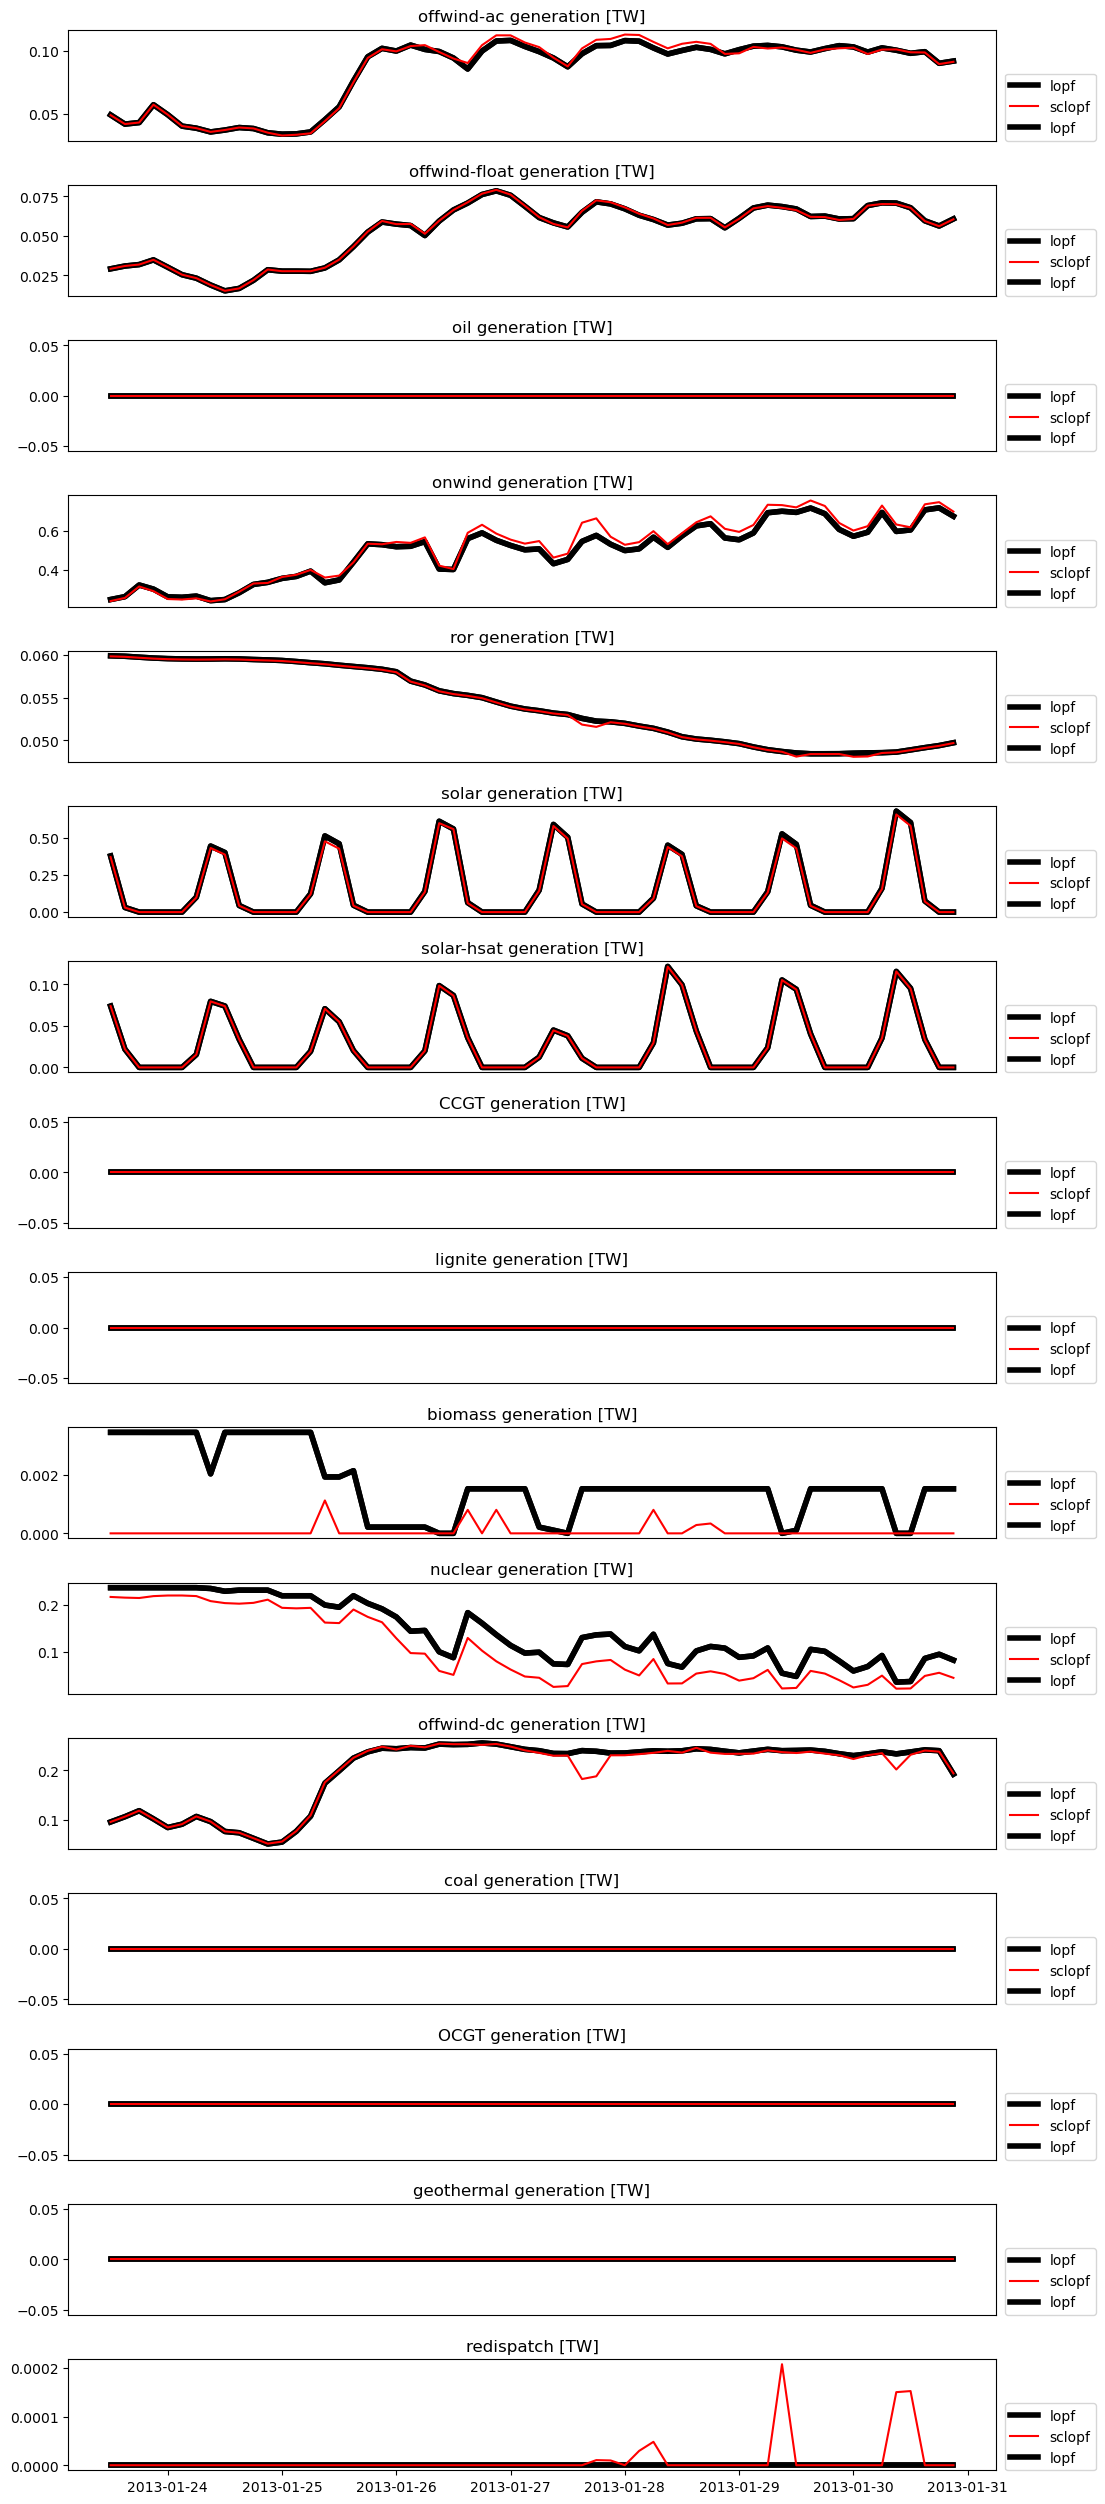

In [22]:
fig, axes = plt.subplots(len(i.generators.carrier.unique()), 1, figsize=(10, 25))
fig.tight_layout()

c = 0
techsu = i.generators.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_i = (
        i.generators_t.p
        .multiply(i.snapshot_weightings.objective,axis=0).T
        .multiply(i.generators.sign,axis=0)
        .groupby(i.generators.carrier).sum()
        .T[tech].loc[snapshots]/1e6
    )
    if tech == "load":
        disp_n = 0*disp_i
        ax.set_title("redispatch [TW]")
    else:
        disp_n = n.generators_t.p.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.generators.carrier).sum().T[tech].loc[snapshots]/1e6
        ax.set_title(tech + " generation [TW]")
        ax.set_xticks([], [])

    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.legend(loc=[1.01, 0])
    c = c+1

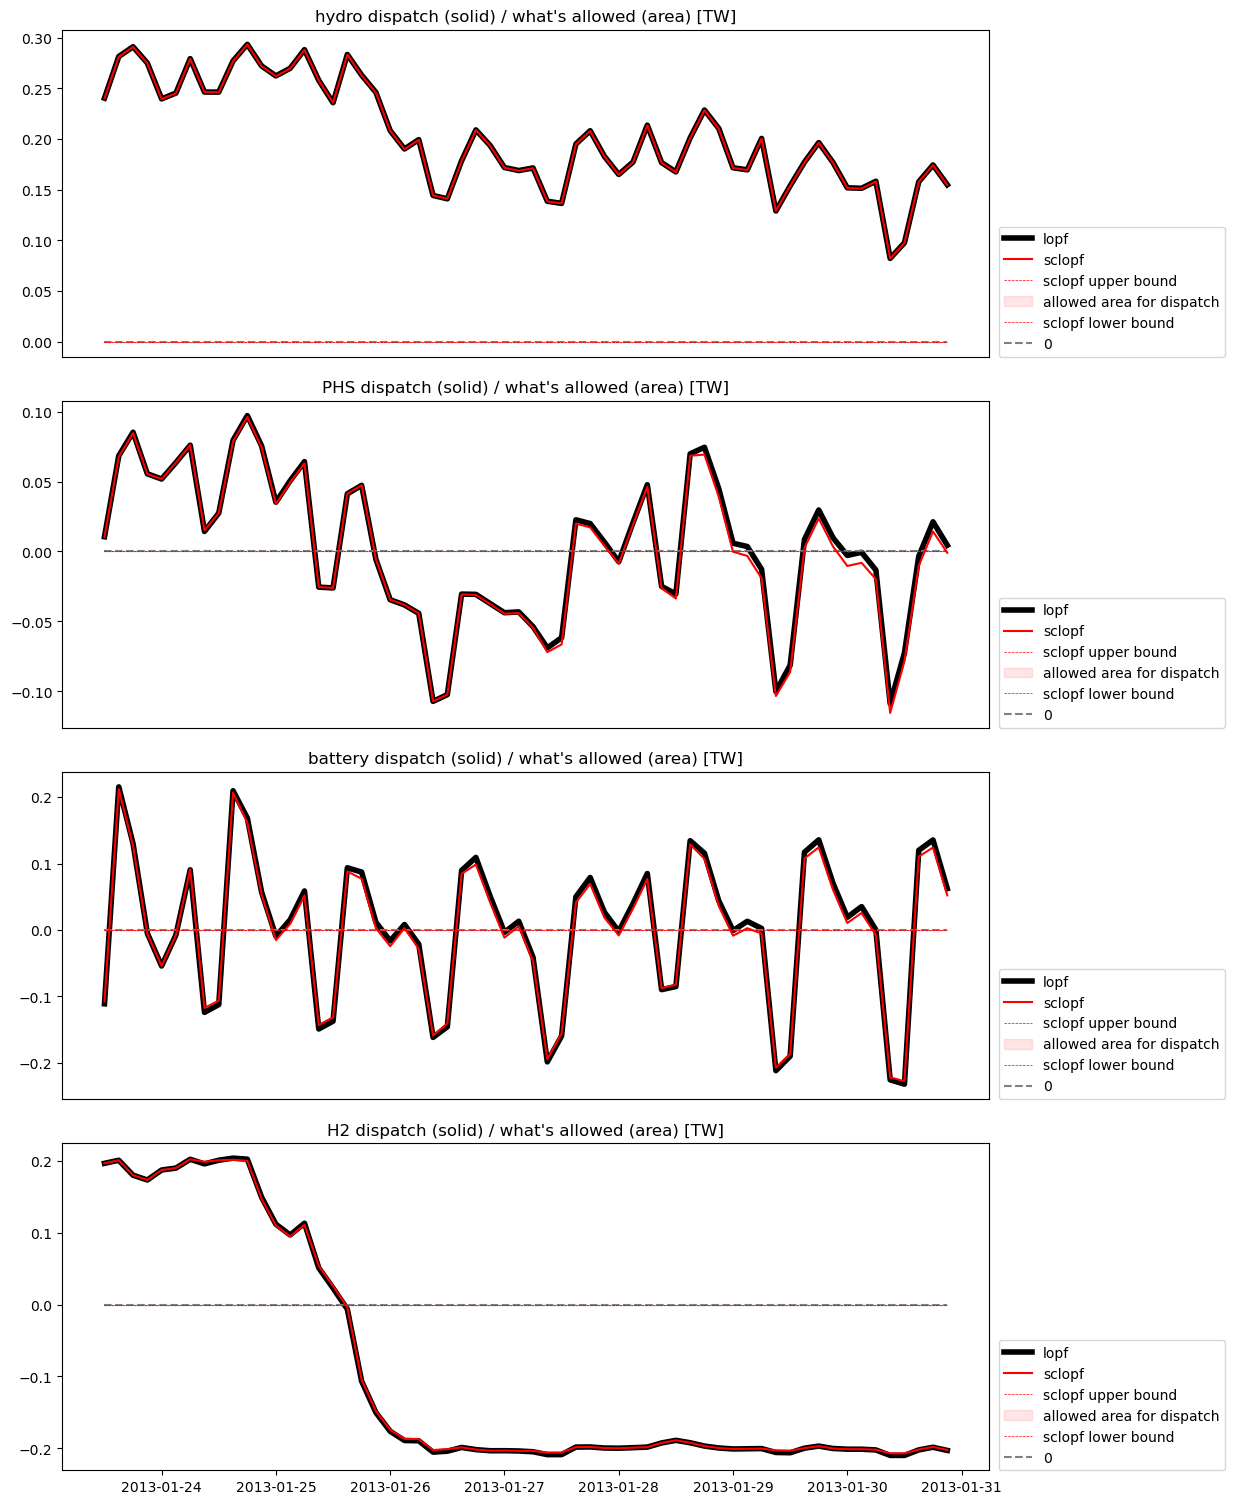

In [23]:
fig, axes = plt.subplots(len(n.storage_units.carrier.unique()), 1, figsize=(10, 15))
fig.tight_layout()

c = 0
techsu = n.storage_units.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_n = n.storage_units_t.p.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_a = i.storage_units_t.p_max_pu.multiply(i.snapshot_weightings.objective,axis=0).multiply(i.storage_units.p_nom).T.groupby(n.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_s = i.storage_units_t.p_min_pu.multiply(i.snapshot_weightings.objective,axis=0).multiply(i.storage_units.p_nom).T.groupby(n.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_i = i.storage_units_t.p.multiply(i.snapshot_weightings.objective,axis=0).T.groupby(i.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6

    ax.set_title(tech + " dispatch (solid) / what's allowed (area) [TW]")
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.plot(disp_a, "--", color="red", linewidth=0.5, zorder=10, label="sclopf upper bound")
    ax.fill_between(snapshots, disp_a, disp_s, color="red", alpha=0.1, label="allowed area for dispatch")
    ax.plot(disp_s, "--", color="red", linewidth=0.5, zorder=10, label="sclopf lower bound")
    ax.plot([snapshots[0], snapshots[-1]], [0, 0], "--", color="gray", label="0")
    ax.legend(loc=[1.01, 0])
    if tech != "H2": ax.set_xticks([], [])
    c = c+1

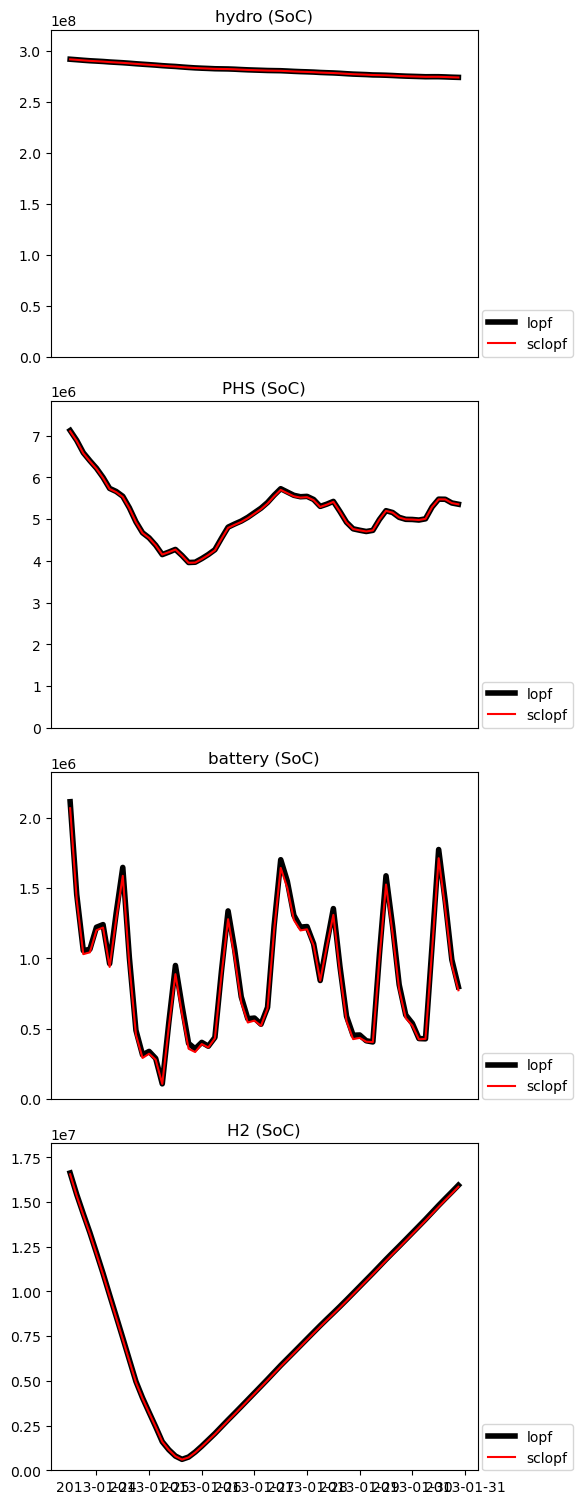

In [24]:
fig, axes = plt.subplots(len(n.storage_units.carrier.unique()), 1, figsize=(5, 15))
fig.tight_layout()

c = 0
techsu = n.storage_units.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_n = n.storage_units_t.state_of_charge.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.storage_units.carrier).sum().T[tech].loc[snapshots]
    disp_i = i.storage_units_t.state_of_charge.multiply(i.snapshot_weightings.objective,axis=0).T.groupby(i.storage_units.carrier).sum().T[tech].loc[snapshots]

    ax.set_title(tech + " (SoC)")
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.set_ylim([min([0, min(disp_n), min(disp_i)]), max([max(disp_n*1.1), max(disp_i*1.1)])])
    ax.legend(loc=[1.01, 0])
    if tech != "H2": ax.set_xticks([], [])
    c = c+1